In [120]:
import pyreadr
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import xarray as xr
import numpy as np
import pandas as pd
from scipy.special import expit 
import os

In [121]:
path_base = "/glade/derecho/scratch/brendanc/fates_output/constco2/"

In [122]:
ds_ddbh   = xr.open_dataset(path_base + "fates_SSP245_ctsm5.3.085_2015-2069.clm2.h1a.FATES_DDBH_latlon.nc")
ds_nplant = xr.open_dataset(path_base + "fates_SSP245_ctsm5.3.085_2015-2069.clm2.h1a.FATES_NPLANT_latlon.nc")

ddb = ds_ddbh["FATES_DDBH_latlon"]       
npl = ds_nplant["FATES_NPLANT_latlon"]   

ddb = ddb.sel(time=ddb['time'].dt.month.isin([4,5,6,7,8,9]))
npl = npl.sel(time=npl['time'].dt.month.isin([4,5,6,7,8,9]))

ddb = ddb.sum(dim="fates_levscls")
npl = npl.sum(dim="fates_levscls")


npl = npl.where(npl > 0)

divide = (ddb / npl)
diameter_mm_yr = divide * 1000
radial_mm_yr = diameter_mm_yr * 0.5

rad = radial_mm_yr

rad = rad.assign_coords(lon=(((rad.lon + 180) % 360) - 180)).sortby('lon')
euro_hist = rad.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [123]:
euro_hist_mean = euro_hist.mean(dim='time')

In [124]:
pfts = [6]

euro_hist_mean = euro_hist_mean.sel(fates_levpft=pfts)

euro_hist_mean = euro_hist_mean.where(euro_hist_mean != 0, np.nan)

euro_hist_mean = euro_hist_mean.mean(dim="fates_levpft")

In [125]:
import os
import numpy as np
import xarray as xr

fd = '/glade/derecho/scratch/brendanc/VPD/growth_model/nonlin'

def load_da(filename):
    ds = xr.open_dataset(os.path.join(fd, filename))
    return ds['__xarray_dataarray_variable__']

abies_hist        = load_da('abies_alba_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fagus_hist        = load_da('fagus_sylvatica_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
fraxinus_hist     = load_da('fraxinus_excelsior_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
picea_hist        = load_da('picea_abies_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pet_hist  = load_da('quercus_petraea_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
quercus_pub_hist  = load_da('quercus_pubescens_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')
pinus_hist        = load_da('pinus_sylvestris_HIST_Europe_annual_radial_growth_1978-2014_nonlin.nc')

years_hist = np.arange(1978, 2015)

def fix_hist(da):
    return da.assign_coords(time=("time", years_hist))

abies_hist        = fix_hist(abies_hist)
fagus_hist        = fix_hist(fagus_hist)
fraxinus_hist     = fix_hist(fraxinus_hist)
picea_hist        = fix_hist(picea_hist)
quercus_pet_hist  = fix_hist(quercus_pet_hist)
quercus_pub_hist  = fix_hist(quercus_pub_hist)
pinus_hist        = fix_hist(pinus_hist)

abies_justVPD        = load_da('abies_alba_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
fagus_justVPD        = load_da('fagus_sylvatica_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
fraxinus_justVPD     = load_da('fraxinus_excelsior_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
picea_justVPD        = load_da('picea_abies_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
quercus_pet_justVPD  = load_da('quercus_petraea_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
quercus_pub_justVPD  = load_da('quercus_pubescens_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')
pinus_justVPD        = load_da('pinus_sylvestris_SSP245_007_Europe_annual_radial_growth_2015-2069_nonlin_justVPD.nc')

years_future = np.arange(2015, 2071)

def fix_future(da):
    return da.assign_coords(time=("time", years_future))

abies_justVPD        = fix_future(abies_justVPD)
fagus_justVPD        = fix_future(fagus_justVPD)
fraxinus_justVPD     = fix_future(fraxinus_justVPD)
picea_justVPD        = fix_future(picea_justVPD)
quercus_pet_justVPD  = fix_future(quercus_pet_justVPD)
quercus_pub_justVPD  = fix_future(quercus_pub_justVPD)
pinus_justVPD        = fix_future(pinus_justVPD)

In [126]:
hist_all = xr.concat(
    [
        abies_hist.fillna(0),
        fagus_hist.fillna(0),
        fraxinus_hist.fillna(0),
        picea_hist.fillna(0),
        quercus_pet_hist.fillna(0),
        quercus_pub_hist.fillna(0),
        pinus_hist.fillna(0)
    ],
    dim="species"
)

In [127]:
hist_baseline = hist_all.sel(time=slice(2005, 2014)).mean("time")

In [128]:
justVPD_all = xr.concat(
    [
        abies_justVPD.fillna(0),
        fagus_justVPD.fillna(0),
        fraxinus_justVPD.fillna(0),
        picea_justVPD.fillna(0),
        quercus_pet_justVPD.fillna(0),
        quercus_pub_justVPD.fillna(0),
        pinus_justVPD.fillna(0)
    ],
    dim="species"
)

In [129]:
pct_change_all = 100 * (justVPD_all - hist_baseline) / hist_baseline

In [130]:
species_names = [
    "abies", "fagus", "fraxinus", "picea",
    "quercus_pet", "quercus_pub", "pinus"
]

pct_change_all = pct_change_all.assign_coords(
    species=("species", species_names)
)

In [131]:

sp = "abies"
year = 2056

da = pct_change_all.sel(species=sp, time=year)

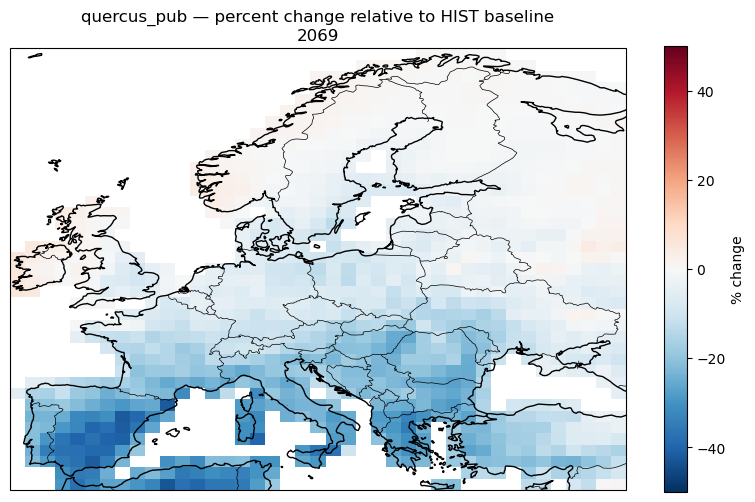

In [132]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

sp = "quercus_pub"
year = 2069

da = pct_change_all.sel(species=sp, time=year)

plt.figure(figsize=(8,5))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    da.lon, da.lat, da,
    cmap="RdBu_r",
    shading="auto",
    vmin=-50, vmax=50
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_title(f"{sp} — percent change relative to HIST baseline\n{year}")

cbar = plt.colorbar(pcm)
cbar.set_label("% change")

plt.tight_layout()
plt.show()

In [133]:
conifer_names = ["abies", "picea", "pinus"]
broadleaf_names = ["fagus", "fraxinus", "quercus_pet", "quercus_pub"]
conifers_pct = pct_change_all.sel(species=conifer_names).mean("species", skipna=True)
broadleaves_pct = pct_change_all.sel(species=broadleaf_names).mean("species", skipna=True)
conifers_pct = conifers_pct.isel(time=slice(0, -1))
broadleaves_pct = broadleaves_pct.isel(time=slice(0, -1))

In [134]:
conifers_pct = conifers_pct.rename({"time": "year"})
broadleaves_pct = broadleaves_pct.rename({"time": "year"})

In [135]:
conifers_pct = conifers_pct.fillna(0)
broadleaves_pct = broadleaves_pct.fillna(0)

In [136]:
euro_hist_yearly = euro_hist.groupby("time.year").mean("time", skipna=True)

In [137]:
pfts = [1, 2, 3, 4, 5, 6]

euro_2015 = euro_hist_yearly.sel(fates_levpft=pfts, year=2025)

euro_2015 = euro_2015.where(euro_2015 != 0, np.nan)

euro_2015_mean = euro_2015.mean(dim="fates_levpft")

In [138]:
euro_pft1_6 = euro_hist_yearly.sel(fates_levpft=slice(1, 6))

euro_pft1_6 = euro_pft1_6.fillna(0)

conifers_pct = conifers_pct.assign_coords(
    lat=("lat", euro_pft1_6.lat.values),
    lon=("lon", euro_pft1_6.lon.values)
)

broadleaves_pct = broadleaves_pct.assign_coords(
    lat=("lat", euro_pft1_6.lat.values),
    lon=("lon", euro_pft1_6.lon.values)
)

conifer_pfts     = [1, 3]
broadleaf_pfts   = [5, 6]

scale_array = xr.full_like(euro_pft1_6, fill_value=0)

scale_array = scale_array.assign_coords(
    fates_levpft=("fates_levpft", euro_pft1_6.fates_levpft.values)
)

scale_array.loc[dict(fates_levpft=conifer_pfts)] = conifers_pct

scale_array.loc[dict(fates_levpft=broadleaf_pfts)] = broadleaves_pct

euro_pft1_6_scaled = euro_pft1_6 * (1 + scale_array / 100)

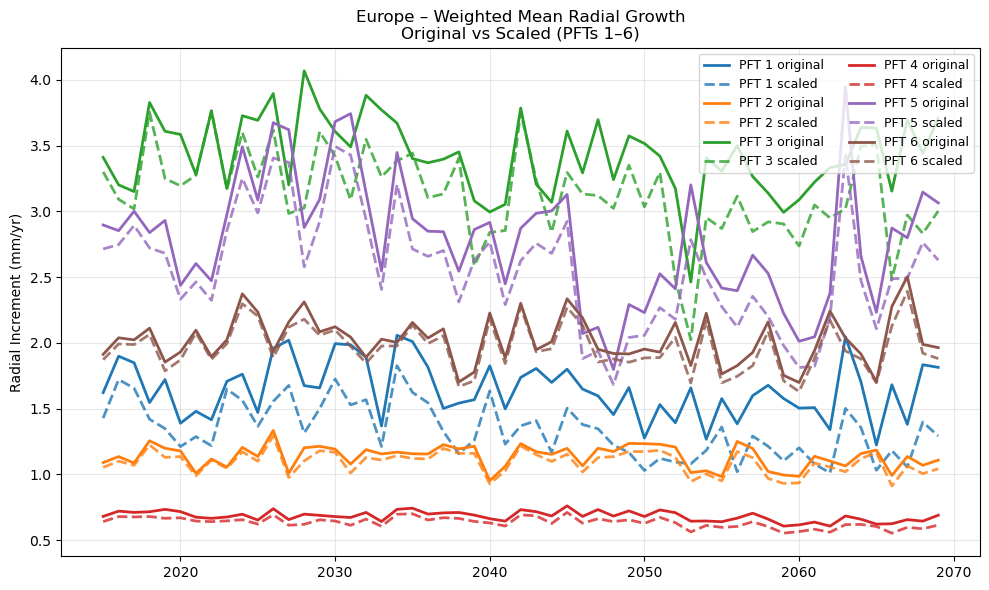

In [139]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

conifers_pct = conifers_pct.assign_coords(
    lat=("lat", euro_hist_yearly.lat.values),
    lon=("lon", euro_hist_yearly.lon.values)
)

broadleaves_pct = broadleaves_pct.assign_coords(
    lat=("lat", euro_hist_yearly.lat.values),
    lon=("lon", euro_hist_yearly.lon.values)
)

weights = np.cos(np.deg2rad(euro_hist_yearly.lat))
weights = weights / weights.mean()

ts_orig_all = {}
ts_scaled_all = {}

for pft in range(1, 7):

    # extract yearly series for this PFT
    da = euro_hist_yearly.sel(fates_levpft=pft)

    # replace zeros with NaN
    da = da.where(da != 0, np.nan)

    # determine if conifer or broadleaf
    if pft in conifer_pfts:
        pct = conifers_pct
    else:
        pct = broadleaves_pct

    # apply scaling
    da_scaled = da * (1 + pct / 100)
    da_scaled = da_scaled.where(da_scaled != 0, np.nan)

    # compute weighted means
    ts_orig = (da * weights).mean(("lat", "lon"))
    ts_scaled = (da_scaled * weights).mean(("lat", "lon"))

    # store
    ts_orig_all[pft] = ts_orig
    ts_scaled_all[pft] = ts_scaled


plt.figure(figsize=(10,6))

colors = ["tab:blue", "tab:orange", "tab:green",
          "tab:red", "tab:purple", "tab:brown"]

for i, pft in enumerate(range(1, 7)):
    # original
    plt.plot(
        ts_orig_all[pft].year,
        ts_orig_all[pft],
        label=f"PFT {pft} original",
        color=colors[i],
        linewidth=2
    )

    # scaled (dashed)
    plt.plot(
        ts_scaled_all[pft].year,
        ts_scaled_all[pft],
        linestyle="--",
        color=colors[i],
        linewidth=2,
        alpha=0.8,
        label=f"PFT {pft} scaled"
    )

plt.ylabel("Radial Increment (mm/yr)")
plt.title("Europe – Weighted Mean Radial Growth\nOriginal vs Scaled (PFTs 1–6)")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

In [140]:
filedir1 = "/glade/derecho/scratch/brendanc/fates_output/constco2/"
da  = xr.open_dataset(filedir1 + "fates_SSP245_ctsm5.3.085_conCO2_353ppm_fixedbiogeo_2015-2034.clm2.h0a.2015-06.nc")
height = da["FATES_BA_WEIGHTED_HEIGHT"] # units meters

In [141]:
height = height.mean(dim='time')

height = height.assign_coords(lon=(((height.lon + 180) % 360) - 180)).sortby('lon')
height = height.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [142]:
ds_ba   = xr.open_dataset(path_base + "fates_hist_ctsm5.3.085_1989-2014.clm2.h1a.BASALAREAlatlon.nc")
ba = ds_ba["FATES_BASALAREA_latlon"]  #units m2 m-2

In [143]:
ba = ba.sel(time=ba.time.dt.year == 2014).mean("time", skipna=True)

In [144]:
ba = ba.sum(dim="fates_levscls")

In [145]:
ba = ba.assign_coords(lon=(((ba.lon + 180) % 360) - 180)).sortby('lon')
ba = ba.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [146]:
ba_1_6 = ba.sel(fates_levpft=[1,2,3,4,5,6])

ba_mean = ba_1_6.mean("fates_levpft")
ba_mean = ba_mean.where(ba_mean != 0, np.nan)

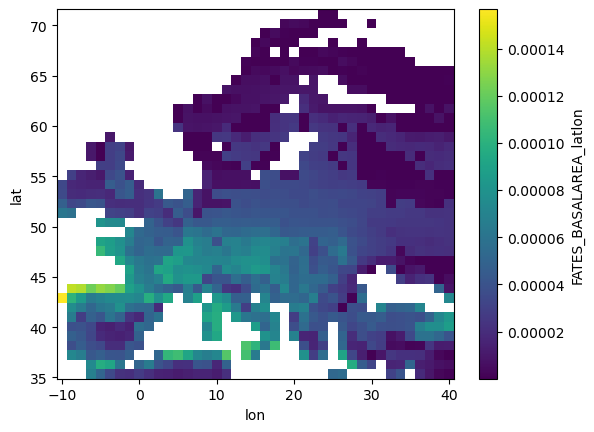

In [147]:
ba_mean.plot()

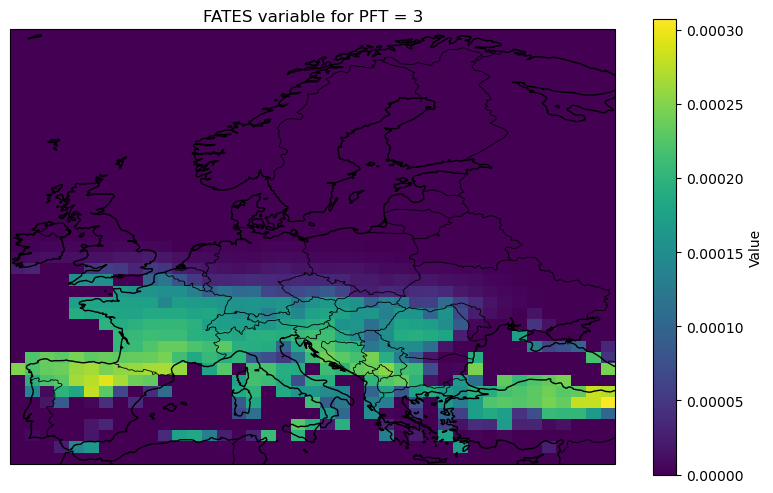

In [148]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ba_pft3 = ba.sel(fates_levpft=4)

plt.figure(figsize=(8,5))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree())

pcm = ax.pcolormesh(
    ba_pft3.lon,
    ba_pft3.lat,
    ba_pft3,
    shading="auto",
    cmap="viridis"
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.6)

plt.title("FATES variable for PFT = 3")
cbar = plt.colorbar(pcm, orientation="vertical")
cbar.set_label("Value")

plt.tight_layout()
plt.show()

In [149]:
ba_pft1_6 = ba.sel(fates_levpft=slice(1, 6))  

height_b = height.broadcast_like(ba_pft1_6)   

rg_default = euro_hist_yearly.sel(fates_levpft=slice(1, 6)) / 1000.0  

rg_scaled  = euro_pft1_6_scaled / 1000.0                                 

rg_default, rg_scaled = xr.align(rg_default, rg_scaled)

In [150]:
def carbon_from_radial(ba_init, height_b, rg_m_per_yr, rhoC=1.0):
    """
    ba_init   : (pft, lat, lon)    initial basal area [m2/m2]
    height_b  : (pft, lat, lon)    tree height per pft [m] (broadcast from height)
    rg_m_per_yr : (year, pft, lat, lon) radial increment [m/yr]
    rhoC      : conversion factor from volume to carbon, e.g. 
                rho_wood * carbon_fraction * form_factor. Leave as 1.0 for 'volume index'.
    
    Returns:
      C : (year, pft, lat, lon) cumulative carbon stock (relative units) over time
      BA: (year, pft, lat, lon) basal area evolution (optional, for diagnostics)
    """
    years = rg_m_per_yr['year']
    pfts  = rg_m_per_yr['fates_levpft']

    # Align shapes and fill NaNs with zero growth/area where missing
    ba_t = ba_init.sel(fates_levpft=pfts).fillna(0)           # (pft, lat, lon)
    h_t  = height_b.sel(fates_levpft=pfts).fillna(0)          # (pft, lat, lon)
    rg   = rg_m_per_yr.fillna(0)                              # (year, pft, lat, lon)

    C_list  = []
    BA_list = []

    # Current basal area state
    BA = ba_t

    for i, y in enumerate(years.values):
        # Equivalent radius r from basal area: BA = π r^2 -> r = sqrt(BA/π)
        r_eq = xr.where(BA > 0, np.sqrt(BA / np.pi), 0.0)

        # Radial increment for this year
        dr = rg.sel(year=y)  # (pft, lat, lon) in m/yr

        # Change in basal area (small-dr approximation)
        dBA = 2.0 * np.pi * r_eq * dr   # (pft, lat, lon) [m2/m2 per year]

        # Update basal area
        BA_new = BA + dBA

        # Incremental volume per ground area
        dV = dBA * h_t   # [m3/m2 per year]

        # Convert to carbon 
        dC = dV * rhoC

        if i == 0:
            C_accum = dC
        else:
            C_accum = C_list[-1] + dC

        C_list.append(C_accum)
        BA_list.append(BA_new)

        BA = BA_new  # carry into next year

    C = xr.concat(C_list, dim="year").assign_coords(year=years)
    BA_out = xr.concat(BA_list, dim="year").assign_coords(year=years)

    return C, BA_out

In [151]:
C_default, BA_default = carbon_from_radial(
    ba_init   = ba_pft1_6,
    height_b  = height_b,
    rg_m_per_yr = rg_default,
    rhoC      = 1.0  # or your preferred carbon conversion factor
)

In [152]:
C_scaled, BA_scaled = carbon_from_radial(
    ba_init   = ba_pft1_6,
    height_b  = height_b,
    rg_m_per_yr = rg_scaled,
    rhoC      = 1.0
)

In [153]:
weights = np.cos(np.deg2rad(C_default.lat))
weights = weights / weights.mean()

ts_C_def = (C_default * weights).mean(("lat","lon"))   
ts_C_scl = (C_scaled * weights).mean(("lat","lon"))  

pft3 = 3
pft6 = 6

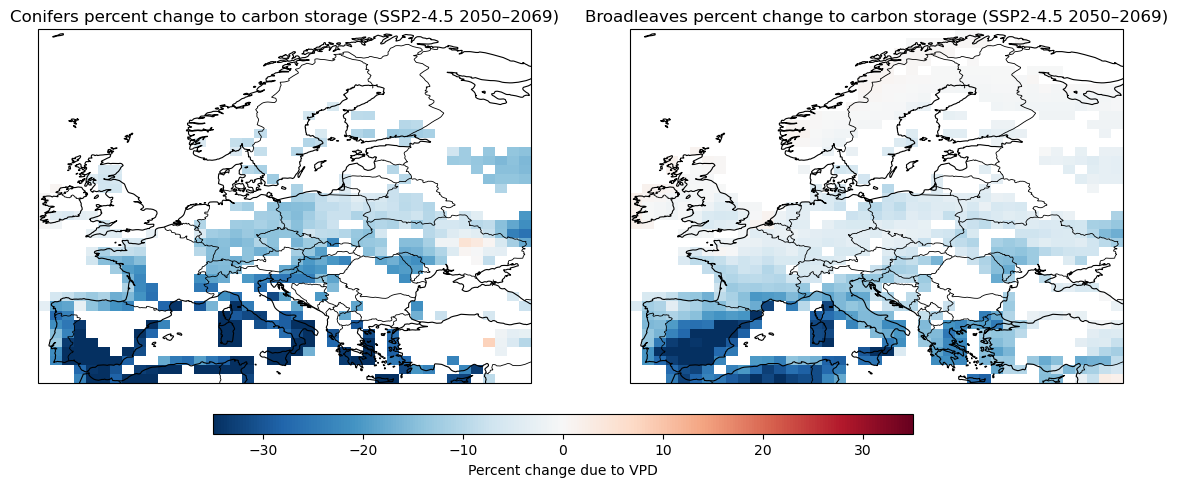

In [154]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

pfts = [1, 2, 3, 4, 5, 6]

default = euro_hist_yearly.sel(fates_levpft=pfts)
scaled  = euro_pft1_6_scaled.sel(fates_levpft=pfts)

default = default.where(default != 0, np.nan)
scaled  = scaled.where(scaled  != 0, np.nan)

pct_change = 100 * (scaled - default) / default

pct_2050_2069 = pct_change.sel(year=slice(2050, 2069)).mean("year")

conifers_mean    = pct_2050_2069.sel(fates_levpft=conifer_pfts).mean("fates_levpft")
broadleaves_mean = pct_2050_2069.sel(fates_levpft=broadleaf_pfts).mean("fates_levpft")

proj = ccrs.PlateCarree()

fig, ax = plt.subplots(
    1, 2, figsize=(14, 5), subplot_kw={"projection": proj}
)

for axis in ax:
    axis.coastlines(linewidth=0.8)
    axis.add_feature(cfeature.BORDERS, linewidth=0.6)
    axis.set_xticks([]); axis.set_yticks([])

im0 = ax[0].pcolormesh(
    conifers_mean.lon,
    conifers_mean.lat,
    conifers_mean,
    cmap="RdBu_r",
    vmin=-35, vmax=35,
    transform=proj
)
ax[0].set_title("Conifers percent change to carbon storage (SSP2-4.5 2050–2069)")

im1 = ax[1].pcolormesh(
    broadleaves_mean.lon,
    broadleaves_mean.lat,
    broadleaves_mean,
    cmap="RdBu_r",
    vmin=-35, vmax=35,
    transform=proj
)
ax[1].set_title("Broadleaves percent change to carbon storage (SSP2-4.5 2050–2069)")

cbar_ax = fig.add_axes([0.25, 0.04, 0.50, 0.04])   

cbar = fig.colorbar(
    im1, cax=cbar_ax,
    orientation="horizontal"
)
cbar.set_label("Percent change due to VPD")
savedir = "/glade/derecho/scratch/brendanc/make_pft/"
#plt.savefig(f"{savedir}/Correct_fates_carbon_pchange_fates_AGU.png", dpi=300, bbox_inches="tight")
plt.show()

In [155]:
filedir2 = '/glade/campaign/univ/urtg0006/Brendan/nationregrid'
mask = xr.open_dataset(filedir2 + '/gadm0.mask.nc4')
mask=mask.gadm0
IDtxt = np.arange(2,255,1)
IDtxt = IDtxt - 1

In [156]:
tgrid = xr.open_dataset(path_base + '/fates_SSP245_ctsm5.3.085_conCO2_353ppm_fixedbiogeo_2015-2034.clm2.h1a.2015-06.nc')

In [157]:
import xarray as xr
import numpy as np


mask_0360 = ((mask.lon % 360 + 360) % 360)
mask = mask.assign_coords(lon=mask_0360).sortby("lon").sortby("lat")

mask_on_tgrid = mask.interp(
    lat=tgrid.lat,
    lon=tgrid.lon,
    method="nearest"
)

mask_on_tgrid = mask_on_tgrid.round().astype("int32")

print(mask_on_tgrid)

<xarray.DataArray 'gadm0' (lat: 192, lon: 288)> Size: 221kB
array([[-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648],
       [-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648],
       [-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648],
       ...,
       [-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648],
       [-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648],
       [-2147483648, -2147483648, -2147483648, ..., -2147483648,
        -2147483648, -2147483648]], dtype=int32)
Coordinates:
  * lat      (lat) float32 768B -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float32 1kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
Attributes:
    units:          GADM L0 index
    long_name:      253 countries
    _DeflateLevel:  5


/glade/u/home/brendanc/.local/lib/python3.10/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


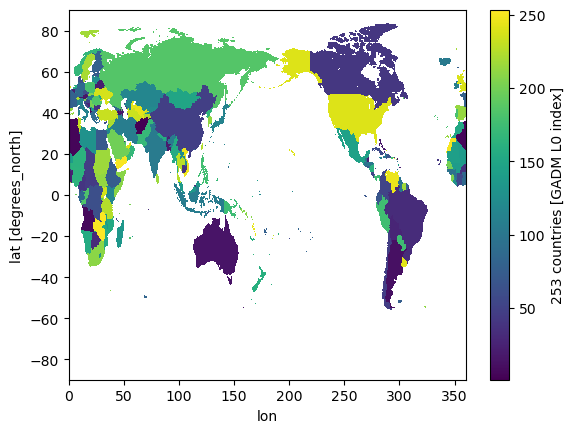

In [158]:
mask.plot()

In [159]:
mask_on_tgrid = mask_on_tgrid.fillna(0)

In [160]:
mask_on_tgrid = mask_on_tgrid.where((mask_on_tgrid > 0) & (mask_on_tgrid < 300))

In [161]:
mask_on_tgrid = mask_on_tgrid.assign_coords(lon=(((mask_on_tgrid.lon + 180) % 360) - 180)).sortby('lon')
mask_on_tgrid = mask_on_tgrid.sel(lat=slice(35, 72), lon=slice(-11, 40))

In [162]:
import xarray as xr
import numpy as np

mask_clean = mask_on_tgrid.where(np.isfinite(mask_on_tgrid) & (mask_on_tgrid != 0))

conifers_mean_country = conifers_mean.groupby(mask_clean).mean()

print(conifers_mean_country)

<xarray.DataArray (gadm0: 44)> Size: 352B
array([-30.15914248, -34.95261497, -15.05460697,  -8.53483096,
                nan, -20.11837874,          nan, -20.95175106,
       -31.79027547, -13.34466842,  -9.85062965,          nan,
       -10.67139713, -17.41451953, -13.17107159, -36.02171769,
                nan, -20.50338293,  -2.31703768, -35.22487639,
                nan,  -8.53119285,  -6.27854004, -17.89240842,
       -20.35278259,          nan, -31.69814652,          nan,
        -7.35840152, -10.3152597 , -25.57099022, -19.55778338,
       -13.96020662, -17.4595744 , -16.72758349, -23.58792908,
       -31.225275  ,  -9.2235993 , -15.29187052,  -9.18812194,
       -35.26480397, -10.61228279,  -8.25539228,  -5.42987687])
Coordinates:
  * gadm0    (gadm0) float64 352B 3.0 4.0 15.0 21.0 ... 231.0 232.0 237.0 239.0


In [163]:
import xarray as xr
import numpy as np

mask_clean = mask_on_tgrid.where(np.isfinite(mask_on_tgrid) & (mask_on_tgrid != 0))

broadleaves_mean_country = broadleaves_mean.groupby(mask_clean).mean()


print(broadleaves_mean_country)

<xarray.DataArray (gadm0: 44)> Size: 352B
array([-13.00160247, -28.05319768,  -6.38479639,  -4.90887281,
        -1.42023645,  -9.24635818, -24.10305363, -10.51533336,
       -15.30612182,  -3.34208924,  -5.46560592,          nan,
        -1.10994231,  -8.86510521,  -4.80989268, -20.3540612 ,
                nan, -11.39230432,   0.20541589, -20.76954109,
                nan,  -4.02382137,  -3.89713771, -10.92806454,
       -16.52161   , -10.21898829, -27.1744495 ,  -2.92359547,
         0.07506902,  -5.7633366 , -19.1197321 , -12.46818465,
        -2.92708517, -10.59289368,  -6.16206369, -13.08178138,
       -25.90907962,  -0.92273029,  -4.67365454,  -4.65534491,
       -25.57736381, -10.45060635,  -8.02225087,  -1.15613172])
Coordinates:
  * gadm0    (gadm0) float64 352B 3.0 4.0 15.0 21.0 ... 231.0 232.0 237.0 239.0


In [164]:
df_con = conifers_mean_country.to_series().reset_index()
df_con.columns = ["country_id", "percent"]
print(df_con.head())

   country_id    percent
0         3.0 -30.159142
1         4.0 -34.952615
2        15.0 -15.054607
3        21.0  -8.534831
4        22.0        NaN


In [165]:
df_broad = broadleaves_mean_country.to_series().reset_index()
df_broad.columns = ["country_id", "percent"]
print(df_broad.head())

   country_id    percent
0         3.0 -13.001602
1         4.0 -28.053198
2        15.0  -6.384796
3        21.0  -4.908873
4        22.0  -1.420236


In [166]:
fd = '/glade/derecho/scratch/brendanc/make_pft'

In [167]:
df_con.to_excel(os.path.join(fd, "Fates_Cvol_scaled_conifers_pft1and3.xlsx"), index=False, engine="openpyxl")

In [168]:
df_broad.to_excel(os.path.join(fd, "Fates_Cvol_scaled_broadleaves_pft1and3.xlsx"), index=False, engine="openpyxl")

In [ ]:
#add country names to column C

In [169]:
import pandas as pd
import plotly as py
import numpy as np
from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
import plotly.graph_objs as go
from plotly.subplots import make_subplots

In [170]:
fd = '/glade/derecho/scratch/brendanc/make_pft'

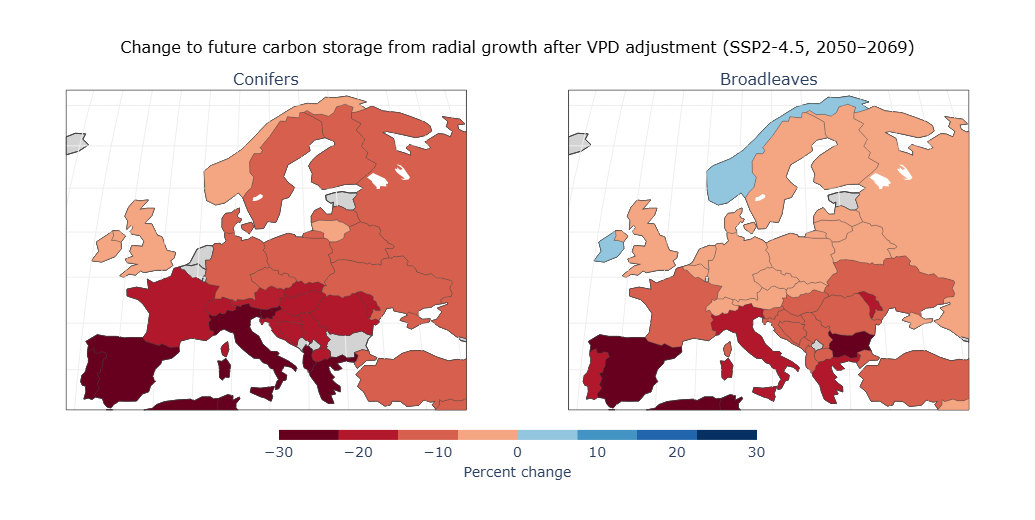

In [179]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

name_fix = {
    "Czech Republic": "Czechia",
    "Macedonia": "North Macedonia",
    "Russia": "Russian Federation",
    "Moldova": "Republic of Moldova",
    "Turkey": "Turkey",
}

def generateDiscreteColourScale(colour_set):
    colour_output = []
    num_colours = len(colour_set)
    divisions = 1.0 / num_colours
    c_index = 0.0
    for cset in colour_set:
        num_subs = len(cset)
        sub_divisions = divisions / num_subs
        for subcset in cset:
            colour_output.append((c_index, subcset))
            colour_output.append((c_index + sub_divisions - 0.001, subcset))
            c_index = c_index + sub_divisions
    colour_output[-1] = (1, colour_output[-1][1])
    return colour_output

color_schemes = [
    ['#67001f','#b2182b','#d6604d','#f4a582'],   # reds
    ['#92c5de','#4393c3','#2166ac','#053061']    # blues
]
cscale = generateDiscreteColourScale(color_schemes)

def load_carbon(path, fd):
    df = pd.read_excel(f"{fd}/{path}", usecols="B,C").iloc[:44, :].copy()
    df["nation-name"] = df["nation-name"].replace(name_fix)
    df["percent"] = df["percent"].astype(float)
    return df

con = load_carbon("Fates_Cvol_scaled_conifers_pft1and3.xlsx", fd)
bro = load_carbon("Fates_Cvol_scaled_broadleaves_pft1and3.xlsx", fd)

both_vals = np.concatenate([con["percent"].values, bro["percent"].values])
vmax = float(np.nanmax(np.abs(both_vals))) if len(both_vals) else 30.0
zmin, zmax = -30, 30   

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "choropleth"}, {"type": "choropleth"}]],
    subplot_titles=(
        "Conifers",
        "Broadleaves"
    ),
    horizontal_spacing=0.01
)

fig.add_trace(
    go.Choropleth(
        locations=con["nation-name"],
        z=con["percent"],
        locationmode="country names",
        coloraxis="coloraxis",
        hovertemplate="<b>%{location}</b><br>Δ tree volume: %{z:.3f} %<extra></extra>",
        marker_line_width=0.3,
    ),
    row=1, col=1
)

fig.add_trace(
    go.Choropleth(
        locations=bro["nation-name"],
        z=bro["percent"],
        locationmode="country names",
        coloraxis="coloraxis",
        hovertemplate="<b>%{location}</b><br>Δ tree volume: %{z:.3f} %<extra></extra>",
        marker_line_width=0.3,
    ),
    row=1, col=2
)

for i in range(1, 3):
    fig.update_geos(
        projection_type="robinson",
        lataxis_range=[35, 71],
        lonaxis_range=[-11, 40],
        showcountries=True,
        showcoastlines=True,
        showland=True,
        landcolor="lightgray",
        lataxis=dict(showgrid=True, dtick=5),
        lonaxis=dict(showgrid=True, dtick=5),
        row=1, col=i
    )

fig.update_layout(
    coloraxis=dict(
        colorscale=cscale,
        cmin=zmin, cmax=zmax,
        colorbar=dict(
            title=dict(text="Percent change", font=dict(size=14)),
            tickfont=dict(size=14),
            orientation="h",
            x=0.5, y=-0.25,
            xanchor="center",
            thickness=10,
            len=0.5,
            title_side="bottom"
        )
    ),
    width=1000, height=520,
    margin=dict(l=20, r=20, t=90, b=110),
    title=dict(
        text="Change to future carbon storage from radial growth after VPD adjustment (SSP2-4.5, 2050–2069)",
        x=0.5, y=0.92,
        xanchor="center", yanchor="top",
        font=dict(size=16, color="black")
    )
)

fig.show()

In [180]:
savedir = "/glade/derecho/scratch/brendanc/fates_output/constco2/GRL_figures"
fig.write_image(savedir+"/GRL_Fig5.png",scale=3)